In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io as sio
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn

from utils import Reservoir, DataGenerator

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ===========================================================
# GLOBAL PLOT STYLE 
# Note: Requires a working LaTeX installation on your system 
# (not in this specific case, the first three lines are commented)
# ===========================================================

plt.rcParams.update({
    # LaTeX and Fonts
    "text.usetex": True,
    "font.family": "cmr10",
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}",
    "font.size": 16,         
    "axes.titlesize": 16,      
    "axes.labelsize": 16,      
    "legend.fontsize": 16,    
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,

    # Line widths
    "axes.linewidth": 1.2,     
    "lines.linewidth": 1.5,    
    "lines.markersize": 8,    

    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,

    # Grid
    "axes.grid": True,
    "grid.linestyle": "dashed",
    "grid.alpha": 0.2,

    # Legend
    "legend.frameon": False,
    "legend.loc": "best"
    })

## Checkloss function

$$\rho_\tau(r) = \tau \max(r, 0) + (1-\tau)\max(-r, 0)$$

In [3]:
def checkloss(taus, ytrue, ypred):
    loss = 0

    # Loop over each tau
    for i, tau in enumerate(taus):
        # Compute the residuals
        r = ytrue - ypred[:, i].unsqueeze(1)
        
        # Compute the loss for a given tau
        quantile_loss = tau * torch.relu(r) + (1 - tau) * torch.relu(-r)
        loss += torch.mean(quantile_loss)
        
    return loss

## Readout layer

In [4]:
class ReadoutMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, activation=nn.ReLU):
        super().__init__()
        layers = []
        prev_dim = input_dim
        
        # Hidden layers
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(activation())
            prev_dim = h_dim
            
        # Output layer
        layers.append(nn.Linear(prev_dim, output_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

## Metrics

In [5]:
# Compute final metrics
def compute_metrics(taus, y_true, y_preds):
    y_true = y_true.flatten()
    idx_median = taus.index(0.50)
    
    mse = np.mean((y_true - y_preds[:, idx_median])**2)
    
    idx_lower = taus.index(0.025)
    idx_upper = taus.index(0.975)
    y_lower = y_preds[:, idx_lower]
    y_upper = y_preds[:, idx_upper]
    
    coverage = np.mean((y_true >= y_lower) & (y_true <= y_upper))
    width = np.mean(y_upper - y_lower)
        
    cal_error = 0
    for i, tau in enumerate(taus):
        emp_tau = np.mean(y_true <= y_preds[:, i])
        cal_error += (tau - emp_tau)**2
        
    crps_sum = 0
    for i, tau in enumerate(taus):
        r = y_true - y_preds[:, i]
        check_loss = np.where(r >= 0, tau * r, (tau - 1) * r)
        crps_sum += np.mean(check_loss)
    
    mcrps = (2*crps_sum)/len(taus) 
    
    print("FINAL METRICS:")
    print(f"MSE: {mse:.4f}")
    print(f"Coverage (95% CI): {coverage * 100:.2f}%")
    print(f"Mean Width (95% CI): {width:.4f}")
    print(f"Calibration error: {cal_error:.4f}")
    print(f"mCRPS: {mcrps:.4f}")
    
    return mse, coverage, width, cal_error, mcrps

# Mackey-Glass dataset analysis

In [6]:
# Data parameters
Time_steps = 14000
tau = 17
n = 10
beta = 0.2
gamma = 0.1
delta_t = 0.1

X, Y = DataGenerator(Time_steps, tau, n, beta, gamma, delta_t).generate_data()

# Clean dataset 
washout = 2000
X = X[washout:]
Y = Y[washout:]  

X = X[::10]
Y = Y[::10]

In [7]:
# Split Train e Test
train_points = int(len(X) * 0.7)

X_train = X[:train_points, :]
Y_train = Y[:train_points, :] 

X_test = X[train_points:, :]
Y_test = Y[train_points:, :]  

# Reservoir
res = Reservoir(input_dim=1, reservoir_dim=500, spectral_radius=0.9, seed=42)
S_train = res.get_states(X_train)
S_test = res.get_states(X_test)

burnin = 100

S_train = S_train[burnin:, :]
Y_train = Y_train[burnin:, :]

S_test = S_test[burnin:, :]
Y_test = Y_test[burnin:, :]

print(f"Input shape: {X_train.shape}")
print(f"Reservoir States shape: {S_train.shape}")

Input shape: (840, 1)
Reservoir States shape: (740, 500)


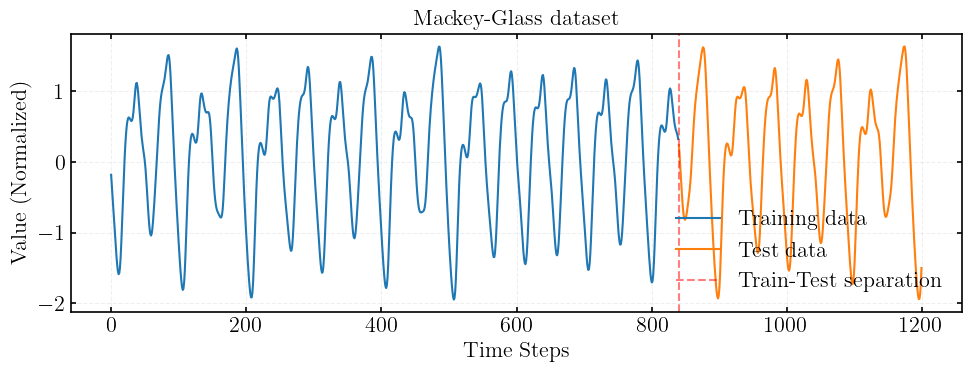

In [8]:
# Plot dataset
plt.figure(figsize=(10, 4))
len_train = len(X_train)
len_test = len(X_test)

plt.plot(range(len_train), X_train, label="Training data")
plt.plot(range(len_train, len_train + len_test), X_test, label="Test data")

plt.axvline(x=len_train, color="red", linestyle="--", alpha=0.5, label="Train-Test separation")

plt.title("Mackey-Glass dataset")
plt.xlabel("Time Steps")
plt.ylabel("Value (Normalized)")
plt.legend(loc="best", frameon=False)
plt.tight_layout()
plt.show()

In [9]:
# Recast data to torch tensors
Xtrain_tensor = torch.tensor(S_train, dtype=torch.float32)
Ytrain_tensor = torch.tensor(Y_train, dtype=torch.float32)
Xtest_tensor = torch.tensor(S_test, dtype=torch.float32)
Ytest_tensor = torch.tensor(Y_test, dtype=torch.float32)

## Train the net

## Grid search on paper suggested parameters

In [10]:
# Hyperparameters to tune
param_grid = { # n.b. for now I tested only the paper suggested parameters, but we can expand them later if needed
    "hidden_dims": [ [512], [512, 256], [512, 256, 128] ], # test 1, 2 or 3 layers
    "activations": [nn.ReLU, nn.Tanh],
    "learning_rates": [0.1, 0.01, 0.001, 0.0005]
}

# Define quantiles for median and 95% confidence interval (switch to:
# taus = [0.05, 0.50, 0.95] # if we want to test only the paper suggested quantiles (90% CI) )
taus = [0.025, 0.50, 0.975] 
epochs = 100 

best_mse = float("inf")
best_params = None
best_model = None
best_train_losses = []
best_val_losses = []

print("\nSTARTING GRID SEARCH...")

# Loop over all combinations of hyperparameters
for hdim in param_grid["hidden_dims"]:
    for act in param_grid["activations"]:
        for lr in param_grid["learning_rates"]:
            
            # Initialize model and optimizer
            model = ReadoutMLP(input_dim=Xtrain_tensor.shape[1], hidden_dims=hdim, output_dim=len(taus), activation=act)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            
            train_losses = []
            val_losses = []
            
            # Training loop
            for epoch in range(epochs):
                model.train()
                optimizer.zero_grad()
                
                # Forward and Train Loss
                train_preds = model(Xtrain_tensor)
                loss = checkloss(taus, Ytrain_tensor, train_preds) 
                loss.backward()
                optimizer.step()
                
                train_losses.append(loss.item())
                
                # Validation Loss tracking
                model.eval()
                with torch.no_grad():
                    val_preds = model(Xtest_tensor)
                    v_loss = checkloss(taus, Ytest_tensor, val_preds)
                    val_losses.append(v_loss.item())
            
            # Evaluate using MSE of the median as they did in the paper
            model.eval()
            with torch.no_grad():
                final_val_preds = model(Xtest_tensor)
                median_preds = final_val_preds[:, 1].unsqueeze(1)
                mse = torch.mean((Ytest_tensor - median_preds)**2).item()
            
            print(f"\nTested Config: Layers={len(hdim)}, activation={act.__name__}, lr={lr}, mse: {mse:.4f}")
            
            # 4. Save the best model
            if mse < best_mse:
                best_mse = mse
                best_params = {"hidden_dims": hdim, "activation": act.__name__, "lr": lr}
                best_model = model
                best_train_losses = train_losses
                best_val_losses = val_losses
                print("New best model found!")

print(f"\nBEST MODEL:")
print(f"Parameters: {best_params}")
print(f"Validation MSE: {best_mse:.4f}")


STARTING GRID SEARCH...

Tested Config: Layers=1, activation=ReLU, lr=0.1, mse: 1616.0941
New best model found!

Tested Config: Layers=1, activation=ReLU, lr=0.01, mse: 0.1274
New best model found!

Tested Config: Layers=1, activation=ReLU, lr=0.001, mse: 0.0127
New best model found!

Tested Config: Layers=1, activation=ReLU, lr=0.0005, mse: 0.0022
New best model found!

Tested Config: Layers=1, activation=Tanh, lr=0.1, mse: 28.7223

Tested Config: Layers=1, activation=Tanh, lr=0.01, mse: 0.4371

Tested Config: Layers=1, activation=Tanh, lr=0.001, mse: 0.0432

Tested Config: Layers=1, activation=Tanh, lr=0.0005, mse: 0.0014
New best model found!

Tested Config: Layers=2, activation=ReLU, lr=0.1, mse: 1.0492

Tested Config: Layers=2, activation=ReLU, lr=0.01, mse: 0.0140

Tested Config: Layers=2, activation=ReLU, lr=0.001, mse: 0.0020

Tested Config: Layers=2, activation=ReLU, lr=0.0005, mse: 0.0006
New best model found!

Tested Config: Layers=2, activation=Tanh, lr=0.1, mse: 2.2098

T

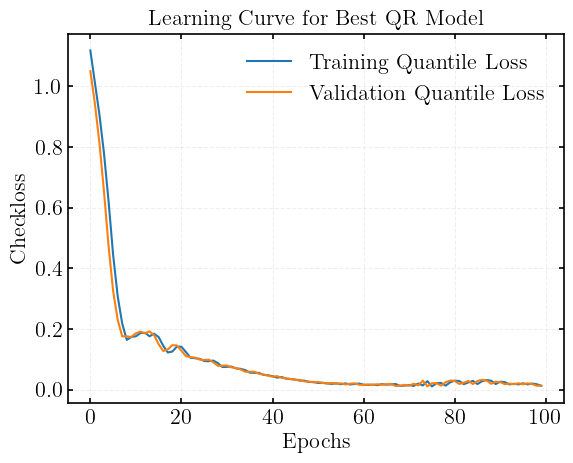

In [11]:
# Learning curve 
plt.figure()
plt.plot(best_train_losses, label="Training Quantile Loss", color="tab:blue")
plt.plot(best_val_losses, label="Validation Quantile Loss", color="tab:orange")

plt.xlabel("Epochs")
plt.ylabel("Checkloss")
plt.title(f"Learning Curve for Best QR Model")
plt.legend(frameon=False, loc="best")

plt.show()

## Training on the best model

In [12]:
# Final Training on the best model
best_activation = getattr(nn, best_params["activation"]) 

# Initialize the best model
best_model = ReadoutMLP(input_dim=Xtrain_tensor.shape[1], hidden_dims=best_params["hidden_dims"], output_dim=len(taus), activation=best_activation)
optimizer = torch.optim.Adam(best_model.parameters(), lr=best_params["lr"])

# Train for many epochs
epochs = 100  
train_losses = []
val_losses = []
train_mses = []
val_mses = []

print(f"Train the best model for {epochs} epochs with best params: {best_params}...")
# Training loop
for epoch in range(epochs):
    best_model.train()
    optimizer.zero_grad()
    
    # Forward and loss on training
    train_preds = best_model(Xtrain_tensor)
    loss = checkloss(taus, Ytrain_tensor, train_preds)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    # Compute metrics on Validation set
    best_model.eval()
    with torch.no_grad():
        val_preds = best_model(Xtest_tensor)
        v_loss = checkloss(taus, Ytest_tensor, val_preds)
        val_losses.append(v_loss.item())
        
        val_median = val_preds[:, 1].unsqueeze(1)
        v_mse = torch.mean((Ytest_tensor - val_median)**2).item()
        val_mses.append(v_mse)

print(f"Training completed! Final MSE on Validation set: {val_mses[-1]:.4f}")

Train the best model for 100 epochs with best params: {'hidden_dims': [512, 256, 128], 'activation': 'ReLU', 'lr': 0.0005}...
Training completed! Final MSE on Validation set: 0.0004


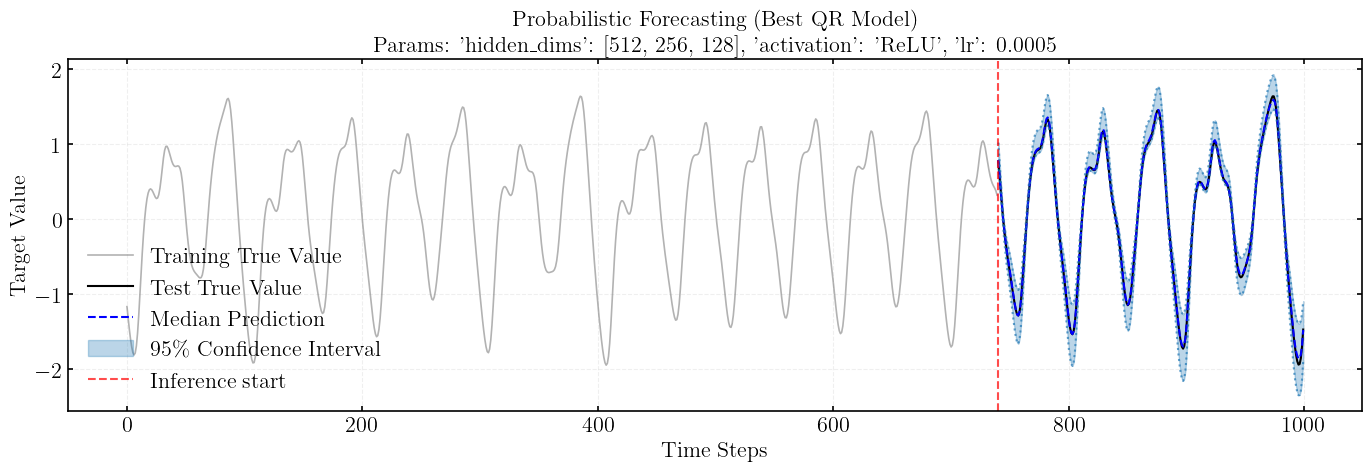

In [13]:
best_model.eval()
with torch.no_grad():
    test_predictions = best_model(Xtest_tensor)

# Extract quantiles
y_pred_025 = test_predictions[:, 0].numpy()
y_pred_50  = test_predictions[:, 1].numpy()
y_pred_975 = test_predictions[:, 2].numpy()

# Extract true values for both Train and Test
y_train_true = Ytrain_tensor.numpy()
y_test_true = Ytest_tensor.numpy()

len_train = len(y_train_true)
len_test = len(y_test_true)

# Plot results
plt.figure(figsize=(14, 5)) 

plt.plot(range(len_train), y_train_true, label="Training True Value", color="gray", alpha=0.6, linewidth=1.2)
plt.plot(range(len_train, len_train + len_test), y_test_true, label="Test True Value", color="black", linewidth=1.5)
plt.plot(range(len_train, len_train + len_test), y_pred_50, label="Median Prediction", color="blue", linestyle="--", linewidth=1.5)
plt.plot(range(len_train, len_train + len_test), y_pred_975, color="tab:blue", linestyle=":", alpha=0.7)
plt.plot(range(len_train, len_train + len_test), y_pred_025, color="tab:blue", linestyle=":", alpha=0.7)

plt.fill_between(range(len_train, len_train+len_test), y_pred_025.flatten(), y_pred_975.flatten(), 
                 color="tab:blue", alpha=0.3, label=r"95\% Confidence Interval")

plt.axvline(x=len_train, color='red', linestyle='--', alpha=0.7, label="Inference start")

plt.xlabel("Time Steps")
plt.ylabel("Target Value")
plt.title(f"Probabilistic Forecasting (Best QR Model)\nParams: {best_params}")
plt.legend(loc="best", frameon=False)

plt.tight_layout()
plt.savefig("qr_mg_prediction.pdf")
plt.show()

In [14]:
qr_mg_metrics = compute_metrics(taus, y_test_true, test_predictions.numpy())

FINAL METRICS:
MSE: 0.0004
Coverage (95% CI): 100.00%
Mean Width (95% CI): 0.3827
Calibration error: 0.1462
mCRPS: 0.0116


In [15]:
# Save the metrics
qr_mg_mse = qr_mg_metrics[0]
qr_mg_coverage = qr_mg_metrics[1]
qr_mg_width = qr_mg_metrics[2]
qr_mg_cal_error = qr_mg_metrics[3]
qr_mg_mcrps = qr_mg_metrics[4]

# fMRI dataset analysis

In [16]:
print("Loading, filtering and scaling data for fMRI...")

train_mat = sio.loadmat("100307.REST1.LR.SchaeferS.ptseries.mat")
test_mat = sio.loadmat("100307.REST2.LR.SchaeferS.ptseries.mat")

train_data = train_mat["tseries"].T
test_data = test_mat["tseries"].T

scaler_train = StandardScaler()
scaler_test = StandardScaler() 
train_scaled = scaler_train.fit_transform(train_data)
test_scaled = scaler_test.fit_transform(test_data) 

target_reg = 0  

X_train = train_scaled[:-1, :]
Y_train = train_scaled[1:, target_reg].reshape(-1, 1)

X_test = test_scaled[:-1, :]
Y_test = test_scaled[1:, target_reg].reshape(-1, 1)

print(f"Shape X_train: {X_train.shape}, Shape Y_train: {Y_train.shape}")
print(f"Shape X_test:  {X_test.shape}, Shape Y_test:  {Y_test.shape}")

Loading, filtering and scaling data for fMRI...
Shape X_train: (1199, 119), Shape Y_train: (1199, 1)
Shape X_test:  (1199, 119), Shape Y_test:  (1199, 1)


In [17]:
# Initialize Reservoir
res = Reservoir(input_dim=X_train.shape[1], 
                reservoir_dim=500, 
                spectral_radius=0.9,
                seed=42)

S_train = res.get_states(X_train)
S_test  = res.get_states(X_test)

Xtrain_tensor = torch.from_numpy(S_train).float()
Ytrain_tensor = torch.from_numpy(Y_train).float()

Xtest_tensor = torch.from_numpy(S_test).float()
Ytest_tensor = torch.from_numpy(Y_test).float()

In [18]:
# Setup Grid Serarch
param_grid = { 
    "hidden_dims": [ [], [32], [64, 32], [128, 64, 32], [512, 256] ],
    "activations": [nn.Tanh, nn.ReLU],
    "learning_rates": [0.001, 0.005, 0.01, 0.1]
}

# Define quantiles and epochs
taus = [0.025, 0.50, 0.975] 
epochs = 100

best_mse = float("inf")
best_params = None
best_model = None
best_train_losses = []
best_val_losses = []


print("STARTING GRID SEARCH...")
for hdim in param_grid["hidden_dims"]:
    for act in param_grid["activations"]:
        for lr in param_grid["learning_rates"]:
            
            model = ReadoutMLP(input_dim=Xtrain_tensor.shape[1], hidden_dims=hdim, output_dim=len(taus), activation=act)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-2)
            
            train_losses = []
            val_losses = []
            
            for epoch in range(epochs):
                model.train()
                optimizer.zero_grad()
                
                train_preds = model(Xtrain_tensor)
                
                # Sort the quantiles
                train_preds, _ = torch.sort(train_preds, dim=1) 
                
                # Compute the loss
                loss = checkloss(taus, Ytrain_tensor, train_preds) 
                loss.backward()
                optimizer.step()
                
                train_losses.append(loss.item())
                
                model.eval()
                with torch.no_grad():
                    val_preds = model(Xtest_tensor)
                    val_preds, _ = torch.sort(val_preds, dim=1)
                    v_loss = checkloss(taus, Ytest_tensor, val_preds)
                    val_losses.append(v_loss.item())
            
            model.eval()
            with torch.no_grad():
                final_val_preds = model(Xtest_tensor)
                final_val_preds, _ = torch.sort(final_val_preds, dim=1)
                median_preds = final_val_preds[:, 1].unsqueeze(1)
                mse = torch.mean((Ytest_tensor - median_preds)**2).item()
            
            print(f"\nConfig: Layers={len(hdim)}, Activation={act.__name__}, lr={lr}, MSE: {mse:.4f}")
            
            if mse < best_mse:
                best_mse = mse
                best_params = {"hidden_dims": hdim, "activation": act.__name__, "lr": lr}
                best_model = model
                best_train_losses = train_losses
                best_val_losses = val_losses
                print("New best model found!")

print(f"\nBEST MODEL:")
print(f"Parameters: {best_params}")
print(f"Validation MSE: {best_mse:.4f}")

STARTING GRID SEARCH...

Config: Layers=0, Activation=Tanh, lr=0.001, MSE: 0.9651
New best model found!

Config: Layers=0, Activation=Tanh, lr=0.005, MSE: 1.1502

Config: Layers=0, Activation=Tanh, lr=0.01, MSE: 1.3505

Config: Layers=0, Activation=Tanh, lr=0.1, MSE: 1.5268

Config: Layers=0, Activation=ReLU, lr=0.001, MSE: 0.9731

Config: Layers=0, Activation=ReLU, lr=0.005, MSE: 1.1808

Config: Layers=0, Activation=ReLU, lr=0.01, MSE: 1.2520

Config: Layers=0, Activation=ReLU, lr=0.1, MSE: 1.4675

Config: Layers=1, Activation=Tanh, lr=0.001, MSE: 0.9196
New best model found!

Config: Layers=1, Activation=Tanh, lr=0.005, MSE: 1.0711

Config: Layers=1, Activation=Tanh, lr=0.01, MSE: 1.0507

Config: Layers=1, Activation=Tanh, lr=0.1, MSE: 0.9927

Config: Layers=1, Activation=ReLU, lr=0.001, MSE: 0.8591
New best model found!

Config: Layers=1, Activation=ReLU, lr=0.005, MSE: 1.0389

Config: Layers=1, Activation=ReLU, lr=0.01, MSE: 0.9978

Config: Layers=1, Activation=ReLU, lr=0.1, MSE: 1

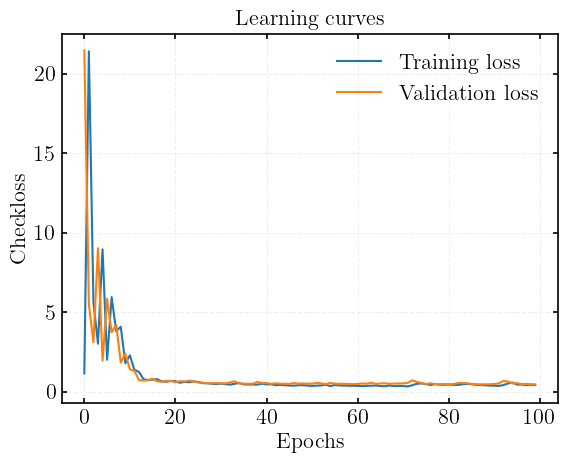

In [19]:
# Plot of losses curves
plt.figure()
plt.plot(best_train_losses, label="Training loss")
plt.plot(best_val_losses, label="Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Checkloss")
plt.title("Learning curves")

plt.legend(frameon=False)
plt.grid(True, linestyle="dashed", alpha=0.2)
plt.show()

In [20]:
print("Final trainig on best model...")

best_activation = getattr(nn, best_params["activation"]) 

best_model = ReadoutMLP(input_dim=Xtrain_tensor.shape[1], hidden_dims=best_params["hidden_dims"], output_dim=len(taus), activation=best_activation)
optimizer = torch.optim.Adam(best_model.parameters(), lr=best_params["lr"], weight_decay=1e-2)

epochs_final = 100  
val_mses = []

for epoch in range(epochs_final):
    best_model.train()
    optimizer.zero_grad()
    
    train_preds = best_model(Xtrain_tensor)
    train_preds, _ = torch.sort(train_preds, dim=1) 
    loss = checkloss(taus, Ytrain_tensor, train_preds)
    loss.backward()
    optimizer.step()
    
    best_model.eval()
    with torch.no_grad():
        val_preds = best_model(Xtest_tensor)
        val_preds, _ = torch.sort(val_preds, dim=1)
        val_median = val_preds[:, 1].unsqueeze(1)
        v_mse = torch.mean((Ytest_tensor - val_median)**2).item()
        val_mses.append(v_mse)

print(f"Training completed! Final MSE on Validation set: {val_mses[-1]:.4f}")

best_model.eval()
with torch.no_grad():
    test_predictions = best_model(Xtest_tensor)
    test_predictions, _ = torch.sort(test_predictions, dim=1)

y_pred_025 = test_predictions[:, 0].numpy()
y_pred_50  = test_predictions[:, 1].numpy()
y_pred_975 = test_predictions[:, 2].numpy()
y_true = Ytest_tensor.numpy()

Final trainig on best model...
Training completed! Final MSE on Validation set: 0.7274


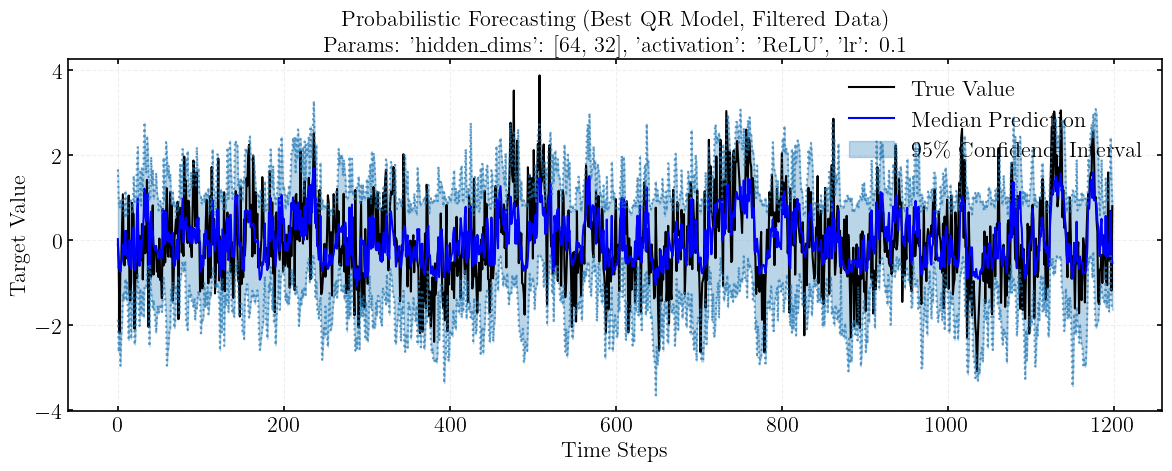

In [21]:
# Final plot
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True Value", color="black", linewidth=1.5)
plt.plot(y_pred_50, label="Median Prediction", color="blue", linewidth=1.5)
plt.plot(y_pred_975, color="tab:blue", linestyle=":", alpha=0.7)
plt.plot(y_pred_025, color="tab:blue", linestyle=":", alpha=0.7)
plt.fill_between(range(y_true.shape[0]), y_pred_025.flatten(), y_pred_975.flatten(), color="tab:blue", alpha=0.3, label=r"95\% Confidence Interval")

plt.xlabel("Time Steps")
plt.ylabel("Target Value")
plt.title(f"Probabilistic Forecasting (Best QR Model, Filtered Data)\nParams: {best_params}")
plt.legend(loc="best", frameon=False)
plt.tight_layout()
plt.savefig("qr_fmri_prediction.pdf")
plt.show()

In [22]:
qr_fmri_metrics = compute_metrics(taus, y_true, test_predictions.numpy())

FINAL METRICS:
MSE: 0.7274
Coverage (95% CI): 87.16%
Mean Width (95% CI): 2.8646
Calibration error: 0.0037
mCRPS: 0.3027


In [23]:
# Save the metrics
qr_fmri_mse = qr_fmri_metrics[0]
qr_fmri_coverage = qr_fmri_metrics[1]
qr_fmri_width = qr_fmri_metrics[2]
qr_fmri_cal_error = qr_fmri_metrics[3]
qr_fmri_mcrps = qr_fmri_metrics[4]

In [24]:
# Consider all regions
X_train_all = train_scaled[:-1, :]
Y_train_all = train_scaled[1:, :]

X_test_all = test_scaled[:-1, :]
Y_test_all = test_scaled[1:, :]

num_regions = Y_train_all.shape[1]
print(f"Number of regions: {num_regions}")
print(f"Shape X_train: {X_train_all.shape}, Shape Y_train: {Y_train_all.shape}")
print(f"Shape X_test:  {X_test_all.shape}, Shape Y_test:  {Y_test_all.shape}")

S_train_all = res.get_states(X_train_all)
S_test_all = res.get_states(X_test_all)

Xtrain_tensor = torch.from_numpy(S_train_all).float()
Ytrain_tensor = torch.from_numpy(Y_train_all).float()
Xtest_tensor = torch.from_numpy(S_test_all).float()
Ytest_tensor = torch.from_numpy(Y_test_all).float()

# Checkloss multi region
def multi_checkloss(taus, y_true, y_pred):
    y_true_exp = y_true.unsqueeze(-1) 
    taus_tensor = torch.tensor(taus, device=y_pred.device).view(1, 1, -1)
    
    r = y_true_exp - y_pred
    loss = torch.max(taus_tensor * r, (taus_tensor - 1) * r)
    return loss.mean() 

# Setup some parameters
taus = [0.025, 0.50, 0.975] 
epochs_final = 100
lr = 0.005

out_dim_total = num_regions * len(taus)

best_model = ReadoutMLP(input_dim=Xtrain_tensor.shape[1], hidden_dims=[], output_dim=out_dim_total, activation=nn.Identity)
optimizer = torch.optim.Adam(best_model.parameters(), lr=lr, weight_decay=1e-2)

train_losses = []
val_mses = []

print(f"\nTraining (Output dim: {out_dim_total}) for {epochs_final} epochs...")
for epoch in range(epochs_final):
    best_model.train()
    optimizer.zero_grad()
    
    train_preds = best_model(Xtrain_tensor).view(-1, num_regions, len(taus))
    
    train_preds, _ = torch.sort(train_preds, dim=2) 
    
    loss = multi_checkloss(taus, Ytrain_tensor, train_preds)
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # Compute validation
    best_model.eval()
    with torch.no_grad():
        val_preds = best_model(Xtest_tensor).view(-1, num_regions, len(taus))
        val_preds, _ = torch.sort(val_preds, dim=2)
        val_median = val_preds[:, :, 1] 
        v_mse = torch.mean((Ytest_tensor - val_median)**2).item()
        val_mses.append(v_mse)
        
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, train Loss: {loss.item():.4f}, mse: {v_mse:.4f}")

print(f"Training completed! Final mse: {val_mses[-1]:.4f}")

with torch.no_grad():
    test_predictions = best_model(Xtest_tensor).view(-1, num_regions, len(taus))
    test_predictions, _ = torch.sort(test_predictions, dim=2)

# Extract the medians for all regions
y_pred_50_all = test_predictions[:, :, 1].numpy()  
y_true_all = Ytest_tensor.numpy()                 

y_true_scaled = y_true_all.T
y_mean_scaled = y_pred_50_all.T

Number of regions: 119
Shape X_train: (1199, 119), Shape Y_train: (1199, 119)
Shape X_test:  (1199, 119), Shape Y_test:  (1199, 119)

Training (Output dim: 357) for 100 epochs...
Epoch 0, train Loss: 0.3077, mse: 0.9002
Epoch 10, train Loss: 0.1759, mse: 0.7608
Epoch 20, train Loss: 0.1704, mse: 0.7501
Epoch 30, train Loss: 0.1738, mse: 0.7506
Epoch 40, train Loss: 0.1736, mse: 0.7486
Epoch 50, train Loss: 0.1722, mse: 0.7473
Epoch 60, train Loss: 0.1722, mse: 0.7475
Epoch 70, train Loss: 0.1724, mse: 0.7473
Epoch 80, train Loss: 0.1723, mse: 0.7474
Epoch 90, train Loss: 0.1723, mse: 0.7473
Training completed! Final mse: 0.7473


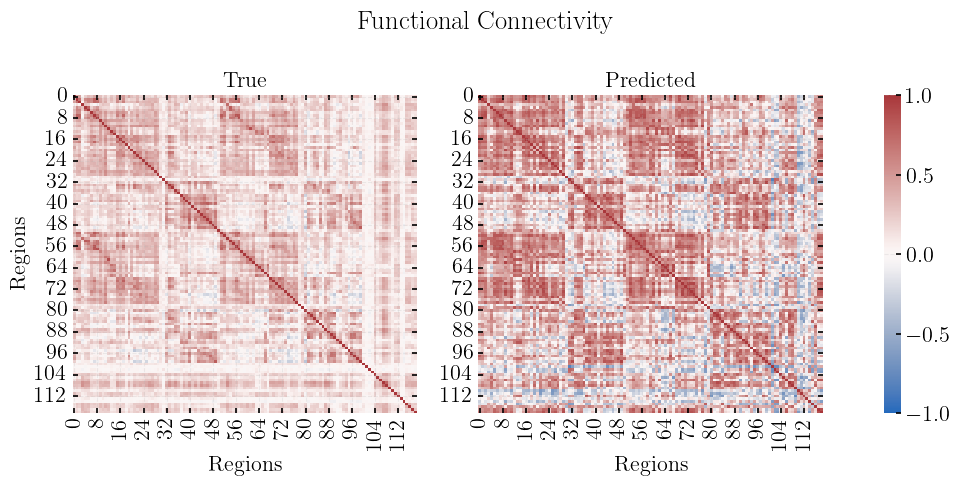

In [25]:
# Plot the functional connectivity heatmaps
fig, ax = plt.subplots(1, 3, figsize=(10, 5), gridspec_kw={'width_ratios': [1, 1, 0.05]})
fig.suptitle("Functional Connectivity")

# True
corr_true = np.corrcoef(y_true_scaled) 
sns.heatmap(corr_true, vmin=-1, vmax=1, cmap='vlag', ax=ax[0], cbar=False)
ax[0].set_title("True")
ax[0].set_xlabel("Regions")
ax[0].set_ylabel("Regions")

# Predicted
corr_pred = np.corrcoef(y_mean_scaled)
sns.heatmap(corr_pred, vmin=-1, vmax=1, cmap='vlag', ax=ax[1], cbar=True, cbar_ax=ax[2])
ax[1].set_title("Predicted")
ax[1].set_xlabel("Regions")

plt.tight_layout()
plt.savefig("qr_fmri_functional_connectivity.pdf")
plt.show()